# Prepare the Environment

In [1]:
############ CREATE VIRTUAL ENVIRONMENT ############

## Python 3.8.16

## From terminal;
# python -m venv scorecard_env
# source scorecard_env/bin/activate
# pip install jupyterlab ipykernel ipywidgets
# which python3

In [2]:
############ ADD VENV TO JUPYTER NOTEBOOK VENV LIST ############

# python -m ipykernel install --user --name=scorecard_env
## Restart kernel to activate

In [3]:
############ ACTIVATE VIRTUAL ENV ############

# jupyter kernelspec list
# which python3

In [4]:
############ UNINSTALL VIRTUAL ENV ############

## If you need to remove a venv;
# jupyter kernelspec uninstall scorecard_env

In [5]:
############ INSTALL REQUIRED PACKAGES ############

## The below lines of code first upgrade the pip library, then install the libraries specified in requirements.txt
# pip install --upgrade pip
# pip install -r requirements.txt

In [6]:
############ IMPORT LIBRARIES ############

from QNBAnalytics_ML import data
from QNBAnalytics_ML import skills_api
from QNBAnalytics_ML.feature_importances import plot_feature_importances
from QNBAnalytics_ML.param_grid_best import grids as param_grid_best
import pandas as pd
import numpy as np
import pickle
import datetime
import os
import time

version = "training"
start_time = datetime.datetime.now()

In [7]:
############ ENTER PARAMETERS ############

index_col = "MUQAVILE"  # index column
target_col = "TARGET"  # target column


## (OPTIONAL)

cols_to_drop = [
    "CC_O_4M6MWPS_EVER","ALL_O_4M6MWPS_EVER_O","ALL_O_7M12MWPS_EVER","ALL_O_7M12MWPS_EVER_O","ALL_OSMLMT_CWPS1_6_EVER",
    "CC_O_13M24MWPS_EVER","CC_O_13M24MWPS_EVER_O","CC_O_7M12MWPS_EVER","CC_O_7M12MWPS_EVER_O","CCOL_O_4M6MWPS_EVER",
    "CL_O_13M24MWPS_EVER_O","HL_EVERWPS_EVER","HL_O_13M24MWPS_365DP","HL_O_3MWPS_365DP","HL_O_4M6MWPS_EVER_O",
    "HL_O_7M12MWPS_EVER_O","HL_O_EVERWPS_365DP","OL_O_3MWPS_183D365D","OL_O_3MWPS_365DP","OL_O_4M6MWPS_183D365D",
    "OL_O_4M6MWPS_91D182D","OL_O_7M12MWPS_365DP","OL_O_EVERWPS_183D365D","OL_O_EVERWPS_365DP","OL_O_EVERWPS_90D",
    "OL_O_EVERWPS_91D182D","OL_OLMTUTL_CWPS0_90D_O","BGN",
############ columns that should not be used for training ############
    "ID", "FIN", "MKR_ID", "MKR_DATE", "IDS", "SCR_CONSTANT", "SCR_MULTIPLIER"
]


In [8]:
############ (OPTIONAL) DATA ORDER IN THE FINAL VERSION ############
############ TO GET THE SAME OUTPUT AS IN FINAL VERSION ############
sorted_indices = pd.read_excel("Data/sorted_indices.xlsx")
sorted_indices_train = sorted_indices.iloc[:85955,0].values
sorted_indices_test = sorted_indices.iloc[85955:,0].values

In [ ]:
############ READ DATA FROM CSV ############

# Auto-select fastest data source
if os.path.exists('Data/data.csv'):
    data_file = 'Data/data.csv'
    read_func = pd.read_csv
    print("✓ Using CSV file (fast loading)")
elif os.path.exists('Data/datamart_full.xlsx'):
    data_file = 'Data/datamart_full.xlsx'
    read_func = pd.read_excel
    print("⚠ Using Excel file (slow - consider running convert_excel_to_csv.py)")
else:
    raise FileNotFoundError("No data file found! Need either data.csv or datamart_full.xlsx")

# Read the complete dataset
print(f"Loading data from {data_file}...")

start_time_load = time.time()
data_full = read_func(data_file)
load_time = time.time() - start_time_load
print(f"Data loaded: {data_full.shape} in {load_time:.1f} seconds")

# Remove rows where TARGET is missing (required for training)
missing_target_count = data_full[target_col].isna().sum()
if missing_target_count > 0:
    print(f"⚠ Warning: Removing {missing_target_count} rows with missing TARGET values")
    data_full = data_full[data_full[target_col].notna()].copy()
    print(f"Data after removing missing targets: {data_full.shape}")

# Split into train and test (first 85,955 for train, rest for test)
train = data_full.iloc[:85955].copy()
test = data_full.iloc[85955:].copy()

print(f"Train size: {train.shape}")
print(f"Test size: {test.shape}")

# Process train data
train = train.set_index(index_col).rename(columns={target_col: "TARGET"})
train = train.reindex(sorted_indices_train) ## TO GET THE SAME OUTPUT AS IN FINAL VERSION
y_train = train["TARGET"]

# Only drop columns that exist in the dataframe (safer approach)
cols_to_drop_existing = [col for col in cols_to_drop if col in train.columns]
x_train = train.drop(columns=["TARGET"]+cols_to_drop_existing, inplace=False)

# Final check: remove any rows with missing target from x_train and y_train
if y_train.isna().any():
    print(f"⚠ Removing {y_train.isna().sum()} rows with missing TARGET from training data")
    valid_idx = y_train.notna()
    y_train = y_train[valid_idx]
    x_train = x_train[valid_idx]

print(f"Training features: {x_train.shape}")
print(f"Training default rate: {y_train.mean():.2%}")

# Process test data
test = test.set_index(index_col).rename(columns={target_col: "TARGET"})
test = test.reindex(sorted_indices_test) ## TO GET THE SAME OUTPUT AS IN FINAL VERSION
y_test = test["TARGET"]

# Only drop columns that exist in the dataframe (safer approach)
cols_to_drop_existing_test = [col for col in cols_to_drop if col in test.columns]
x_test = test.drop(columns=["TARGET"]+cols_to_drop_existing_test, inplace=False)

# Final check: remove any rows with missing target from x_test and y_test
if y_test.isna().any():
    print(f"⚠ Removing {y_test.isna().sum()} rows with missing TARGET from test data")
    valid_idx = y_test.notna()
    y_test = y_test[valid_idx]
    x_test = x_test[valid_idx]

print(f"Test features: {x_test.shape}")
print(f"Test default rate: {y_test.mean():.2%}")

In [11]:
## PIPELINE SETTINGS

apply_data_explore = True
apply_null_elimination = True
apply_constant_elimination = True
apply_null_imputation = True      # BEFORE binning - correct!
apply_binning = True               # PRIMARY encoding method
apply_low_gini_elimination = True  # AFTER binning - correct!
apply_correlated_feature_elimination = True
apply_scaling = False
apply_categorical_encoding = False  # SET TO FALSE - binning handles it!

apply_LR = True

In [12]:
class Pipeline_Base:
    def train(self, x_train, y_train, x_test=[], y_test=[]):
        if (len(x_test) > 0) & (len(y_test) > 0):
            x_val = x_test.copy()
            y_val = y_test.copy()

        self.pipeline = skills_api.ClassifierPipeline(x_train, y_train, x_val, y_val)

        ########################   Data Explore    ############################

        if apply_data_explore:
            self.pipeline.data_explore()


        ########################   Drop Null Features    ############################

        if apply_null_elimination:
            self.pipeline.feature_elimination(eliminator='drop_null_features', params={'threshold': 0.99})


        ########################   Drop Constant Features    ############################

        if apply_constant_elimination:
            self.pipeline.feature_elimination(eliminator='drop_constant_features', params={'missing_values':'ignore'})


        ########################   Null Imputation    ############################

        if apply_null_imputation:
            self.pipeline.null_imputation()


        ########################   Binning (WOE Encoding for ALL features)    ############################
        # THIS IS NOW THE PRIMARY ENCODING METHOD
        # Handles numeric (with binning first) + categorical (directly)

        if apply_binning:
            self.pipeline.binning()


        ########################   Low Gini Elimination    ############################
        # Now all features are WOE-encoded (numeric), so Gini can be calculated

        if apply_low_gini_elimination:
            self.pipeline.feature_elimination(eliminator='drop_low_gini_features', params={'threshold':0.05, 'missing_values':'ignore'})


        ########################   Feature Elimination    ############################

        if apply_correlated_feature_elimination:
            self.pipeline.feature_elimination(eliminator='correlated_lower_gini_feature_elimination', params={'missing_values':'ignore'})


        ########################   Scaling    ############################

        if apply_scaling:
            self.pipeline.scaling()


        #########################      Logistic Regression      #############################

        if apply_LR:
            self.pipeline.LogisticRegression(param_opt=True, param_opt_method = "RandomizedSearchCV", train_size=x_train.shape[0], param_grid = param_grid_best['logistic_regression_base'])


    def apply(self, x_test, y_test=[]):
        predicts = self.pipeline.test(test = x_test, y_test=y_test)
        return predicts

In [ ]:
############ TRAIN MODEL ############

pipeline_base = Pipeline_Base()
pipeline_base.train(x_train = x_train, 
                    y_train = y_train,
                    x_test = x_test, 
                    y_test = y_test)

2025-11-26 00:51:31,183 - qnbanalytics - INFO - There might be multiple ID in dataframe
c:\Users\iasamadov\Desktop\scoring_model\venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\iasamadov\Desktop\scoring_model\venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\iasamadov\Desktop\scoring_model\venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3057: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\Users\iasamadov\Desktop\scoring_model\venv\Lib\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\iasamadov\Desktop\scoring_model\venv\Lib\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(

c:\Users\iasamadov\Desktop\scoring_model\QNBAnalytics_ML\feature_importances.py:208: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=x, y=y, palette=colors)


drop_null_eliminated_features: 955
drop_constant_eliminated_features: 223
low_gini_eliminated_features: 1405
correlation_elimination_eliminated_features: 71
used features: 57


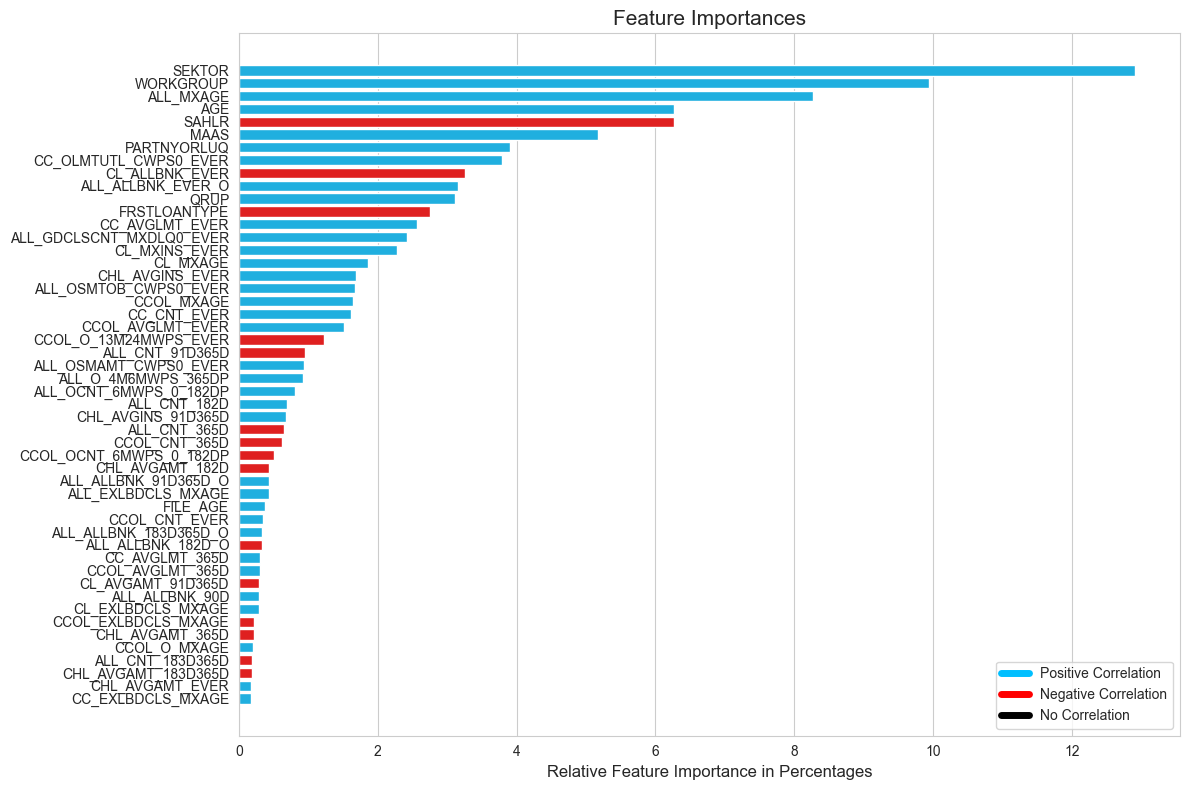

In [ ]:
############ SAVE MODEL ############

model_path = f'Models/base_model_{version}.pkl'
with open(model_path, 'wb') as out:
    pickle.dump(pipeline_base.pipeline, out, pickle.HIGHEST_PROTOCOL)


############ LOAD MODEL ############

# model_path = f'Models/base_model_{version}.pkl'
# with open(model_path, 'rb') as f:
#   pipeline_base = pickle.load(f)




############ FEATURE IMPORTANCE ############
plot_feature_importances(df=pipeline_base.pipeline.logistic_regression_model.model.feature_importances,
                          n=50,
                          save_figure=True,
                          name_ext=f"Base_{version}")


feature_importances = pipeline_base.pipeline.logistic_regression_model.model.feature_importances
pd.DataFrame(feature_importances).to_excel(f"Output/FEATURE_IMPORTANCES_BASE_{version}.xlsx")



binning_table = pipeline_base.pipeline.monotonic_binning.get_binning_table()
pd.DataFrame(binning_table[0]).to_excel(f"Output/BINNING_TABLE_BASE_{version}.xlsx")
pd.DataFrame(binning_table[1]).to_excel(f"Output/GINI_TABLE_BASE_{version}.xlsx")





############ ELIMINATED FEATURES ############

variable_table = pipeline_base.pipeline.variable_table
pd.DataFrame(variable_table).to_excel(f"Output/FEATURES_BASE_{version}.xlsx")


drop_null_eliminated_features = pipeline_base.pipeline.eliminated_features['drop_null_features']
drop_constant_eliminated_features = pipeline_base.pipeline.eliminated_features['drop_constant_features']
low_gini_eliminated_features = pipeline_base.pipeline.eliminated_features['drop_low_gini_features']
correlation_elimination_eliminated_features = pipeline_base.pipeline.eliminated_features['correlated_lower_gini_feature_elimination']
pd.DataFrame(drop_null_eliminated_features, columns=["NULL_ELIMINATED_FEATURES"]).to_excel(f"Output/NULL_ELIMINATED_FEATURES_BASE_{version}.xlsx")
pd.DataFrame(drop_constant_eliminated_features, columns=["CONSTANT_ELIMINATED_FEATURES"]).to_excel(f"Output/CONSTANT_ELIMINATED_FEATURES_BASE_{version}.xlsx")
pd.DataFrame(low_gini_eliminated_features, columns=["GINI_ELIMINATED_FEATURES"]).to_excel(f"Output/GINI_ELIMINATED_FEATURES_BASE_{version}.xlsx")
pd.DataFrame(correlation_elimination_eliminated_features, columns=["CORR_ELIMINATED_FEATURES"]).to_excel(f"Output/CORR_ELIMINATED_FEATURES_BASE_{version}.xlsx")


print(
"""drop_null_eliminated_features: %d
drop_constant_eliminated_features: %d
low_gini_eliminated_features: %d
correlation_elimination_eliminated_features: %d
used features: %d""" % (len(drop_null_eliminated_features), len(drop_constant_eliminated_features), len(low_gini_eliminated_features), len(correlation_elimination_eliminated_features), sum(variable_table.use == True)))

In [ ]:
############ PERFORMANCE OF THE BASE MODEL (LAYER_1) ############

############ BASIC PIPELINE RESULTS ############

base_test_proba_dict = pipeline_base.apply(x_test, y_test)
base_test_proba = base_test_proba_dict["".join(key for key in base_test_proba_dict if "Logistic Regression" in key)][0]

2025-11-25 18:23:43,646 - qnbanalytics - INFO - Imputation transform started...
2025-11-25 18:23:43,670 - qnbanalytics - INFO - Imputation transform completed...
2025-11-25 18:23:43,747 - qnbanalytics - INFO - Imputation transform started...
2025-11-25 18:23:43,749 - qnbanalytics - INFO - Imputation transform completed...
2025-11-25 18:23:45,356 - qnbanalytics - INFO - Results of Logistic Regression
2025-11-25 18:23:45,357 - qnbanalytics - INFO - Train gini: 0.6019665970434225
2025-11-25 18:23:45,357 - qnbanalytics - INFO - CV gini: 0.5885800621821122
2025-11-25 18:23:45,358 - qnbanalytics - INFO - Valid gini: 0.5800379395885014
2025-11-25 18:23:45,359 - qnbanalytics - INFO - Test gini: 0.5800379395885014



In [ ]:
############ CALCULATE CREDIT SCORES ############

all_x = pd.concat([x_train,x_test], axis = 0)
all_y = pd.concat([y_train,y_test], axis = 0)

# Get predictions and extract the result (self-contained)
result = pipeline_base.apply(all_x, all_y)
# Find the Logistic Regression key
lr_keys = [key for key in result.keys() if "Logistic Regression" in key]
if not lr_keys:
    raise KeyError(f"No 'Logistic Regression' key found. Available keys: {list(result.keys())}")
base_all_proba = result[lr_keys[0]][0]
base_all_proba = pd.DataFrame(base_all_proba, index = all_y.index)


ref=200
odds_at_ref=50
points_to_double=20


default_rate = base_all_proba
default_rate = np.where(default_rate == 0, 0.00001, default_rate)

odds = (1/default_rate)-1

base_all_score = ((np.log(odds)-np.log(odds_at_ref))/np.log(2)) * (points_to_double) + ref
base_all_score = pd.DataFrame(base_all_score, index = all_y.index)



base_all_scores = pd.concat([base_all_proba, base_all_score, all_y], axis = 1)
base_all_scores.columns = ["PROBA","SCORE","TARGET"]
pd.DataFrame(base_all_scores).to_excel(f"Output/MAIN_SCORES_BASE_{version}.xlsx")

print("Base model took: %s" % (datetime.datetime.now()- start_time))

In [ ]:
############ BEGINNING OF THE ADVANCED PIPELINE ############

############ SPLIT DATA FOR LAYER_2 MODELS ############

# Score calibration parameters (same as used in base scoring)
ref = 200
odds_at_ref = 50
points_to_double = 20

good_score_threshold = 180 # goods: 180+ scores 
not_good_score_threshold = 200 # not_goods: 200- scores 
good_threshold = 1 / (np.exp((good_score_threshold-ref) / (points_to_double) * np.log(2) + np.log(odds_at_ref)) + 1)  
not_good_threshold = 1 / (np.exp((not_good_score_threshold-ref) / (points_to_double) * np.log(2) + np.log(odds_at_ref)) + 1)  

# Get predictions (self-contained)
train_preds = pipeline_base.apply(x_train, y_test = y_train)
lr_keys = [key for key in train_preds.keys() if "Logistic Regression" in key]
if not lr_keys:
    raise KeyError(f"No 'Logistic Regression' key found. Available keys: {list(train_preds.keys())}")
lr_key = lr_keys[0]
not_good_indices = train_preds[lr_key][0] >= not_good_threshold
good_indices = train_preds[lr_key][0] < good_threshold


print("Not Good split:\n", pd.concat([train[not_good_indices].TARGET.value_counts(), train[not_good_indices].TARGET.value_counts(normalize=True)], axis = 1))
print("Good split:\n", pd.concat([train[good_indices].TARGET.value_counts(), train[good_indices].TARGET.value_counts(normalize=True)], axis = 1))

train_not_good = train[not_good_indices]
train_good = train[good_indices]

y_train_not_good = train_not_good["TARGET"]
y_train_good = train_good["TARGET"]

# Only drop columns that exist (safer approach)
cols_to_drop_existing = [col for col in cols_to_drop if col in train_not_good.columns]
x_train_not_good = train_not_good.drop(columns=["TARGET"]+cols_to_drop_existing, inplace=False)
x_train_good = train_good.drop(columns=["TARGET"]+cols_to_drop_existing, inplace=False)

In [ ]:
############ CREATE PIPELINE FOR LAYER_2 MODELS ############

apply_data_explore = True
apply_null_elimination = True
apply_constant_elimination = True
apply_null_imputation = True          # BEFORE binning
apply_binning = True                   # PRIMARY encoding method
apply_low_gini_elimination = True      # AFTER binning
apply_correlated_feature_elimination = True
apply_scaling = False                  # For Layer 1 (Base)
apply_categorical_encoding = False     # SKIP - binning handles encoding!
apply_scaling = True
apply_LR = True
apply_RF = True   # Layer 2 only
apply_XGB = True  # Layer 2 only
apply_LGBM = True # Layer 2 only

In [ ]:
class Pipeline_Not_Good:
    """
    Not Good segment pipeline - SAME ORDER as Base
    """

    def train(self, x_train, y_train, x_test=[], y_test=[]):
        if (len(x_test) > 0) & (len(y_test) > 0):
            x_val = x_test.copy()
            y_val = y_test.copy()

        self.pipeline = skills_api.ClassifierPipeline(x_train, y_train, x_val, y_val)

        ########################   Data Explore    ############################

        if apply_data_explore:
            self.pipeline.data_explore()


        ########################   Drop Null Features    ############################

        if apply_null_elimination:
            self.pipeline.feature_elimination(eliminator='drop_null_features', params={'threshold': 0.99})


        ########################   Drop Constant Features    ############################

        if apply_constant_elimination:
            self.pipeline.feature_elimination(eliminator='drop_constant_features', params={'missing_values':'ignore'})


        ########################   Null Imputation    ############################
        # BEFORE binning

        if apply_null_imputation:
            self.pipeline.null_imputation()


        ########################   Binning (WOE Encoding)    ############################
        # PRIMARY encoding - BEFORE elimination

        if apply_binning:
            self.pipeline.binning()


        ########################   Low Gini Elimination    ############################
        # AFTER binning

        if apply_low_gini_elimination:
            self.pipeline.feature_elimination(eliminator='drop_low_gini_features', params={'threshold':0.05, 'missing_values':'ignore'})


        ########################   Feature Elimination    ############################

        if apply_correlated_feature_elimination:
            self.pipeline.feature_elimination(eliminator='correlated_lower_gini_feature_elimination', params={'missing_values':'ignore'})


        ########################   Scaling    ############################
        # For Layer 2, scaling is typically enabled

        if apply_scaling:
            self.pipeline.scaling()


        ########################   Categorical Encoding    ############################
        # SKIP - binning handles it

        # if apply_categorical_encoding and not apply_binning:
        #     self.pipeline.encode_categoricals()


        #########################      Logistic Regression      #############################

        if apply_LR:
            self.pipeline.LogisticRegression(param_opt=True, param_opt_method = "RandomizedSearchCV", train_size=x_train.shape[0], param_grid = param_grid_best['logistic_regression_not_good'])

        #########################      Random Forest      #############################

        if apply_RF:
            self.pipeline.RandomForest(param_opt=True, param_opt_method = "RandomizedSearchCV", train_size=x_train.shape[0], param_grid = param_grid_best['random_forest_not_good'])

        #########################        XGBoost          #############################

        if apply_XGB:
            self.pipeline.XGBoost(param_opt=True, param_opt_method = "RandomizedSearchCV", train_size=x_train.shape[0], param_grid = param_grid_best['xgboost_not_good'])

        #########################      LGBM      #############################

        if apply_LGBM:
            self.pipeline.LGBM(param_opt=True, param_opt_method = "RandomizedSearchCV", train_size=x_train.shape[0], param_grid = param_grid_best['lightgbm_not_good'])

    def apply(self, x_test, y_test=[]):
        predicts = self.pipeline.test(test = x_test, y_test=y_test)
        return predicts

In [ ]:

class Pipeline_Good:
    """
    Good segment pipeline - SAME ORDER as Base
    """

    def train(self, x_train, y_train, x_test=[], y_test=[]):
        if (len(x_test) > 0) & (len(y_test) > 0):
            x_val = x_test.copy()
            y_val = y_test.copy()

        self.pipeline = skills_api.ClassifierPipeline(x_train, y_train, x_val, y_val)

        ########################   Data Explore    ############################

        if apply_data_explore:
            self.pipeline.data_explore()


        ########################   Drop Null Features    ############################

        if apply_null_elimination:
            self.pipeline.feature_elimination(eliminator='drop_null_features', params={'threshold': 0.99})


        ########################   Drop Constant Features    ############################

        if apply_constant_elimination:
            self.pipeline.feature_elimination(eliminator='drop_constant_features', params={'missing_values':'ignore'})


        ########################   Null Imputation    ############################
        # BEFORE binning

        if apply_null_imputation:
            self.pipeline.null_imputation()


        ########################   Binning (WOE Encoding)    ############################
        # PRIMARY encoding - BEFORE elimination

        if apply_binning:
            self.pipeline.binning()


        ########################   Low Gini Elimination    ############################
        # AFTER binning

        if apply_low_gini_elimination:
            self.pipeline.feature_elimination(eliminator='drop_low_gini_features', params={'threshold':0.05, 'missing_values':'ignore'})


        ########################   Feature Elimination    ############################

        if apply_correlated_feature_elimination:
            self.pipeline.feature_elimination(eliminator='correlated_lower_gini_feature_elimination', params={'missing_values':'ignore'})


        ########################   Scaling    ############################
        # For Layer 2, scaling is typically enabled

        if apply_scaling:
            self.pipeline.scaling()


        ########################   Categorical Encoding    ############################
        # SKIP - binning handles it

        # if apply_categorical_encoding and not apply_binning:
        #     self.pipeline.encode_categoricals()


        #########################      Logistic Regression      #############################

        if apply_LR:
            self.pipeline.LogisticRegression(param_opt=True, param_opt_method = "RandomizedSearchCV", train_size=x_train.shape[0], param_grid = param_grid_best['logistic_regression_good'])

        #########################      Random Forest      #############################

        if apply_RF:
            self.pipeline.RandomForest(param_opt=True, param_opt_method = "RandomizedSearchCV", train_size=x_train.shape[0], param_grid = param_grid_best['random_forest_good'])

        #########################        XGBoost          #############################

        if apply_XGB:
            self.pipeline.XGBoost(param_opt=True, param_opt_method = "RandomizedSearchCV", train_size=x_train.shape[0], param_grid = param_grid_best['xgboost_good'])

        #########################      LGBM      #############################

        if apply_LGBM:
            self.pipeline.LGBM(param_opt=True, param_opt_method = "RandomizedSearchCV", train_size=x_train.shape[0], param_grid = param_grid_best['lightgbm_good'])

    def apply(self, x_test, y_test=[]):
        predicts = self.pipeline.test(test = x_test, y_test=y_test)
        return predicts


In [ ]:
############ CREATE TEST DATA FOR LAYER_2 MODELS ############
# Get predictions (self-contained)
test_preds = pipeline_base.apply(x_test = x_test, y_test = y_test)
lr_keys = [key for key in test_preds.keys() if "Logistic Regression" in key]
if not lr_keys:
    raise KeyError(f"No 'Logistic Regression' key found. Available keys: {list(test_preds.keys())}")
lr_key = lr_keys[0]
not_good_indices_test = test_preds[lr_key][0] >= not_good_threshold
good_indices_test = test_preds[lr_key][0] < good_threshold

test_not_good = test[not_good_indices_test]
test_good = test[good_indices_test]

y_test_not_good = test_not_good["TARGET"]
y_test_good = test_good["TARGET"]

# Only drop columns that exist (safer approach)
cols_to_drop_existing_test = [col for col in cols_to_drop if col in test_not_good.columns]
x_test_not_good = test_not_good.drop(columns=["TARGET"]+cols_to_drop_existing_test, inplace=False)
x_test_good = test_good.drop(columns=["TARGET"]+cols_to_drop_existing_test, inplace=False)

############ TRAIN LAYER_2 MODELS ############

pipeline_not_good = Pipeline_Not_Good()
pipeline_not_good.train(x_train=x_train_not_good, y_train=y_train_not_good, x_test = x_test_not_good, y_test = y_test_not_good)

pipeline_good = Pipeline_Good()
pipeline_good.train(x_train=x_train_good, y_train=y_train_good, x_test = x_test_good, y_test = y_test_good)

In [ ]:
############ SELECT BEST MODELS FOR LAYER_2 ############

pipeline_not_good.apply(x_test_not_good, y_test_not_good)
pipeline_good.apply(x_test_good, y_test_good)


2025-11-25 18:31:09,544 - qnbanalytics - INFO - Imputation transform started...
2025-11-25 18:31:09,556 - qnbanalytics - INFO - Imputation transform completed...
2025-11-25 18:31:09,723 - qnbanalytics - INFO - Imputation transform started...
2025-11-25 18:31:09,725 - qnbanalytics - INFO - Imputation transform completed...
2025-11-25 18:31:11,215 - qnbanalytics - INFO - Scaling started...

2025-11-25 18:31:11,217 - qnbanalytics - INFO - Scaling completed.

2025-11-25 18:31:11,223 - qnbanalytics - INFO - Results of Logistic Regression
2025-11-25 18:31:11,224 - qnbanalytics - INFO - Train gini: 0.41865378499901373
2025-11-25 18:31:11,225 - qnbanalytics - INFO - CV gini: 0.3864957784407048
2025-11-25 18:31:11,226 - qnbanalytics - INFO - Valid gini: 0.3022900763358778
2025-11-25 18:31:11,229 - qnbanalytics - INFO - Test gini: 0.3022900763358778

2025-11-25 18:31:11,247 - qnbanalytics - INFO - Results of Random Forest
2025-11-25 18:31:11,247 - qnbanalytics - INFO - Train gini: 0.627693550399

[LightGBM] [Warning] Unknown parameter: silent
[LightGBM] [Warning] Unknown parameter: silent


2025-11-25 18:31:13,104 - qnbanalytics - INFO - Scaling started...

2025-11-25 18:31:13,106 - qnbanalytics - INFO - Scaling completed.

2025-11-25 18:31:13,114 - qnbanalytics - INFO - Results of Logistic Regression
2025-11-25 18:31:13,115 - qnbanalytics - INFO - Train gini: 0.538135612906534
2025-11-25 18:31:13,117 - qnbanalytics - INFO - CV gini: 0.51667934842255
2025-11-25 18:31:13,118 - qnbanalytics - INFO - Valid gini: 0.6500420875420874
2025-11-25 18:31:13,122 - qnbanalytics - INFO - Test gini: 0.6500420875420874

2025-11-25 18:31:13,149 - qnbanalytics - INFO - Results of Random Forest
2025-11-25 18:31:13,150 - qnbanalytics - INFO - Train gini: 0.6881623036759463
2025-11-25 18:31:13,150 - qnbanalytics - INFO - CV gini: 0.44350798629018207
2025-11-25 18:31:13,151 - qnbanalytics - INFO - Valid gini: 0.8531144781144779
2025-11-25 18:31:13,153 - qnbanalytics - INFO - Test gini: 0.8531144781144779

2025-11-25 18:31:13,168 - qnbanalytics - INFO - Results of XGBoost
2025-11-25 18:31:13,1

[LightGBM] [Warning] Unknown parameter: silent
[LightGBM] [Warning] Unknown parameter: silent


{'15.Model: Logistic Regression': [array([1.05191632e-02, 3.21415232e-02, 4.01119168e-03, 7.95764102e-03,
         1.07743836e-02, 1.23081046e-02, 1.69317368e-02, 8.07251041e-03,
         1.87667703e-03, 1.86028896e-02, 4.42916245e-03, 1.24707222e-02,
         5.70958062e-04, 7.40433821e-03, 1.38505460e-02, 3.70859754e-03,
         2.98524198e-03, 4.56134057e-03, 7.59999670e-03, 2.96688102e-02,
         6.75669656e-02, 8.28129472e-03, 1.66350637e-03, 2.99080419e-04,
         2.54300668e-02, 3.70624246e-03, 3.19767900e-03, 4.64756783e-03,
         2.00871765e-02, 1.29547093e-02, 2.57424424e-02, 7.68958380e-04,
         1.45665977e-02, 3.86585799e-03, 2.40099428e-03, 2.63999911e-03,
         8.85550415e-03, 6.56905254e-03, 2.85190787e-02, 2.69618208e-03,
         2.14712828e-03, 2.40712627e-03, 4.71967719e-03, 1.13340272e-02,
         3.94238284e-04, 4.11484088e-03, 3.81001918e-03, 9.51886870e-02,
         7.60974425e-03, 6.20306881e-02, 1.98309392e-03, 4.11519353e-03,
         2.0513121

In [ ]:
############ SAVE MODEL ############

model_path_not_good = f'Models/not_good_model_{version}.pkl'
model_path_good = f'Models/good_model_{version}.pkl'
with open(model_path_not_good, 'wb') as out:  pickle.dump(pipeline_not_good.pipeline, out, pickle.HIGHEST_PROTOCOL)
with open(model_path_good, 'wb') as out:  pickle.dump(pipeline_good.pipeline, out, pickle.HIGHEST_PROTOCOL)

In [ ]:
############ SELECTED MODELS ############

not_good_selected_model = 'Logistic Regression'
good_selected_model = 'LGBM'

not_good_model = 'logistic_regression'
good_model = 'lgbm'


In [ ]:
############ FEATURE IMPORTANCES AND ELIMINATED FEATURES ############

feature_importances_not_good = getattr(pipeline_not_good.pipeline, f'{not_good_model}_model').model.feature_importances
feature_importances_good = getattr(pipeline_good.pipeline, f'{good_model}_model').model.feature_importances

pd.DataFrame(feature_importances_not_good).to_excel(f"Output/FEATURE_IMPORTANCES_NOT_GOOD_{version}.xlsx")
pd.DataFrame(feature_importances_good).to_excel(f"Output/FEATURE_IMPORTANCES_GOOD_{version}.xlsx")

variable_table_not_good = pipeline_not_good.pipeline.variable_table
variable_table_good = pipeline_good.pipeline.variable_table
pd.DataFrame(variable_table_not_good).to_excel(f"Output/FEATURES_NOT_GOOD_{version}.xlsx")
pd.DataFrame(variable_table_good).to_excel(f"Output/FEATURES_GOOD_{version}.xlsx")

drop_null_eliminated_features_not_good = pipeline_not_good.pipeline.eliminated_features['drop_null_features']
drop_null_eliminated_features_good = pipeline_good.pipeline.eliminated_features['drop_null_features']
pd.DataFrame(drop_null_eliminated_features_not_good, columns=["NULL_ELIMINATED_FEATURES"]).to_excel(f"Output/NULL_ELIMINATED_FEATURES_NOT_GOOD_{version}.xlsx")
pd.DataFrame(drop_null_eliminated_features_good, columns=["NULL_ELIMINATED_FEATURES"]).to_excel(f"Output/NULL_ELIMINATED_FEATURES_GOOD_{version}.xlsx")

drop_null_eliminated_features_not_good = pipeline_not_good.pipeline.eliminated_features['drop_constant_features']
drop_null_eliminated_features_good = pipeline_good.pipeline.eliminated_features['drop_constant_features']
pd.DataFrame(drop_null_eliminated_features_not_good, columns=["CONSTANT_ELIMINATED_FEATURES"]).to_excel(f"Output/CONSTANT_ELIMINATED_FEATURES_NOT_GOOD_{version}.xlsx")
pd.DataFrame(drop_null_eliminated_features_good, columns=["CONSTANT_ELIMINATED_FEATURES"]).to_excel(f"Output/CONSTANT_ELIMINATED_FEATURES_GOOD_{version}.xlsx")

low_gini_eliminated_features_not_good = pipeline_not_good.pipeline.eliminated_features['drop_low_gini_features']
low_gini_eliminated_features_good = pipeline_good.pipeline.eliminated_features['drop_low_gini_features']
pd.DataFrame(low_gini_eliminated_features_not_good, columns=["GINI_ELIMINATED_FEATURES"]).to_excel(f"Output/GINI_ELIMINATED_FEATURES_NOT_GOOD_{version}.xlsx")
pd.DataFrame(low_gini_eliminated_features_good, columns=["GINI_ELIMINATED_FEATURES"]).to_excel(f"Output/GINI_ELIMINATED_FEATURES_GOOD_{version}.xlsx")

correlation_elimination_eliminated_features_not_good = pipeline_not_good.pipeline.eliminated_features['correlated_lower_gini_feature_elimination']
correlation_elimination_eliminated_features_good = pipeline_good.pipeline.eliminated_features['correlated_lower_gini_feature_elimination']
pd.DataFrame(correlation_elimination_eliminated_features_not_good, columns=["CORR_ELIMINATED_FEATURES"]).to_excel(f"Output/CORR_ELIMINATED_FEATURES_NOT_GOOD_{version}.xlsx")
pd.DataFrame(correlation_elimination_eliminated_features_good, columns=["CORR_ELIMINATED_FEATURES"]).to_excel(f"Output/CORR_ELIMINATED_FEATURES_GOOD_{version}.xlsx")

In [ ]:
############ GENERATE FEATURES FOR LAYER_3 ############

# TRAIN SET

# Get predictions and extract results (self-contained)
base_train_proba_dict = pipeline_base.apply(x_train, y_train)
lr_keys = [key for key in base_train_proba_dict.keys() if "Logistic Regression" in key]
if not lr_keys:
    raise KeyError(f"No 'Logistic Regression' key found. Available keys: {list(base_train_proba_dict.keys())}")
base_train_proba = base_train_proba_dict[lr_keys[0]][0]

not_good_train_proba_dict = pipeline_not_good.apply(x_train, y_train)
ng_keys = [key for key in not_good_train_proba_dict.keys() if f"{not_good_selected_model}" in key]
if not ng_keys:
    raise KeyError(f"No '{not_good_selected_model}' key found. Available keys: {list(not_good_train_proba_dict.keys())}")
not_good_train_proba = not_good_train_proba_dict[ng_keys[0]][0]

good_train_proba_dict = pipeline_good.apply(x_train, y_train)
g_keys = [key for key in good_train_proba_dict.keys() if f"{good_selected_model}" in key]
if not g_keys:
    raise KeyError(f"No '{good_selected_model}' key found. Available keys: {list(good_train_proba_dict.keys())}")
good_train_proba = good_train_proba_dict[g_keys[0]][0]

base_train_proba = pd.DataFrame(base_train_proba, index = y_train.index)
not_good_train_proba = pd.DataFrame(not_good_train_proba, index = y_train.index)
good_train_proba = pd.DataFrame(good_train_proba, index = y_train.index)

x_train_meta = pd.concat([base_train_proba,good_train_proba,not_good_train_proba], axis = 1)
x_train_meta.columns = ["Base","Good","Not_Good"]
y_train_meta = y_train


# TEST SET

# Get predictions and extract results (self-contained)
base_test_proba_dict = pipeline_base.apply(x_test, y_test)
lr_keys = [key for key in base_test_proba_dict.keys() if "Logistic Regression" in key]
if not lr_keys:
    raise KeyError(f"No 'Logistic Regression' key found. Available keys: {list(base_test_proba_dict.keys())}")
base_test_proba = base_test_proba_dict[lr_keys[0]][0]

not_good_test_proba_dict = pipeline_not_good.apply(x_test, y_test)
ng_keys = [key for key in not_good_test_proba_dict.keys() if f"{not_good_selected_model}" in key]
if not ng_keys:
    raise KeyError(f"No '{not_good_selected_model}' key found. Available keys: {list(not_good_test_proba_dict.keys())}")
not_good_test_proba = not_good_test_proba_dict[ng_keys[0]][0]

good_test_proba_dict = pipeline_good.apply(x_test, y_test)
g_keys = [key for key in good_test_proba_dict.keys() if f"{good_selected_model}" in key]
if not g_keys:
    raise KeyError(f"No '{good_selected_model}' key found. Available keys: {list(good_test_proba_dict.keys())}")
good_test_proba = good_test_proba_dict[g_keys[0]][0]

base_test_proba = pd.DataFrame(base_test_proba, index = y_test.index)
good_test_proba = pd.DataFrame(good_test_proba, index = y_test.index)
not_good_test_proba = pd.DataFrame(not_good_test_proba, index = y_test.index)

x_test_meta = pd.concat([base_test_proba,good_test_proba,not_good_test_proba], axis = 1)
x_test_meta.columns = ["Base","Good","Not_Good"]
y_test_meta = y_test

In [ ]:
############ CREATE PIPELINE AND TRAIN LAYER_3 MODEL ############

apply_data_explore = True
apply_null_elimination = True
apply_constant_elimination = True
apply_null_imputation = True          # BEFORE binning
apply_binning = True                   # PRIMARY encoding method
apply_low_gini_elimination = True      # AFTER binning
apply_correlated_feature_elimination = True
apply_scaling = False                  # For Layer 1 (Base)
apply_categorical_encoding = False     # SKIP - binning handles encoding!

apply_LR = True

In [ ]:

class Pipeline_Meta:
    """
    Meta model pipeline - No preprocessing needed, just model training
    Features are already probabilities from Layer 1 and Layer 2
    """

    def train(self, x_train, y_train, x_test=[], y_test=[]):
        if (len(x_test) > 0) & (len(y_test) > 0):
            x_val = x_test.copy()
            y_val = y_test.copy()

        self.pipeline = skills_api.ClassifierPipeline(x_train, y_train, x_val, y_val)

        ########################   Data Explore    ############################

        if apply_data_explore:
            self.pipeline.data_explore()


        # NO PREPROCESSING for meta model - features are already probabilities
        # Skip: null elimination, constant elimination, imputation, binning, elimination


        #########################      Logistic Regression      #############################

        if apply_LR:
            self.pipeline.LogisticRegression(param_opt=True, param_opt_method = "RandomizedSearchCV", train_size=x_train.shape[0], param_grid = param_grid_best['logistic_regression_meta'])


    def apply(self, x_test, y_test=[]):
        predicts = self.pipeline.test(test = x_test, y_test=y_test)
        return predicts



2025-11-25 18:33:29,263 - qnbanalytics - INFO - No ID detected!
2025-11-25 18:33:29,300 - qnbanalytics - INFO - Data Type Conversion started
2025-11-25 18:33:29,302 - qnbanalytics - INFO - Data Type Conversion completed
2025-11-25 18:33:29,309 - qnbanalytics - INFO - 

2025-11-25 18:33:29,310 - qnbanalytics - INFO - Logistic Regression fitting started.

2025-11-25 18:33:29,312 - qnbanalytics - INFO - This is a binary classification problem.

2025-11-25 18:33:29,468 - qnbanalytics - INFO - Parameter optimization started.

c:\Users\iasamadov\Desktop\scoring_model\venv\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 1 is smaller than n_iter=15. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\iasamadov\Desktop\scoring_model\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will al

Fitting 3 folds for each of 1 candidates, totalling 3 fits


c:\Users\iasamadov\Desktop\scoring_model\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
2025-11-25 18:33:29,927 - qnbanalytics - INFO - Refitting to all data...
c:\Users\iasamadov\Desktop\scoring_model\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
2025-11-25 18:33:30,098 - qnbanalytics - INFO - Results of LogisticRegression(C=80.16389938139379, multi_class='auto', random_state=48)
2025-11-25 18:33:30,099 - qnbanalytics - INFO - Mean CV score:  0.6221983884492819
2025-11-25 18:33:30,099 - qnbanalytics - INFO - Calculating SHAP feature importances...
c:

is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier


c:\Users\iasamadov\Desktop\scoring_model\QNBAnalytics_ML\feature_importances.py:133: UserWarning: Model is linear, disabling fast option...
  warnings.warn("Model is linear, disabling fast option...") if fast else print("")
c:\Users\iasamadov\Desktop\scoring_model\QNBAnalytics_ML\feature_importances.py:138: UserWarning: Your model is LogisticRegression(C=80.16389938139379, multi_class='auto', random_state=48)
  warnings.warn(f"""Your model is {model}""")
c:\Users\iasamadov\Desktop\scoring_model\QNBAnalytics_ML\feature_importances.py:139: UserWarning: If your model is not TreeBased, Linear or Deep Learning model, make sure to use agnostic option and give model as predict_proba function.
  warnings.warn(f"""If your model is not TreeBased, Linear or Deep Learning model, make sure to use agnostic option and give model as predict_proba function.""")
c:\Users\iasamadov\Desktop\scoring_model\QNBAnalytics_ML\feature_importances.py:208: FutureWarning: 

Passing `palette` without assigning `hue`

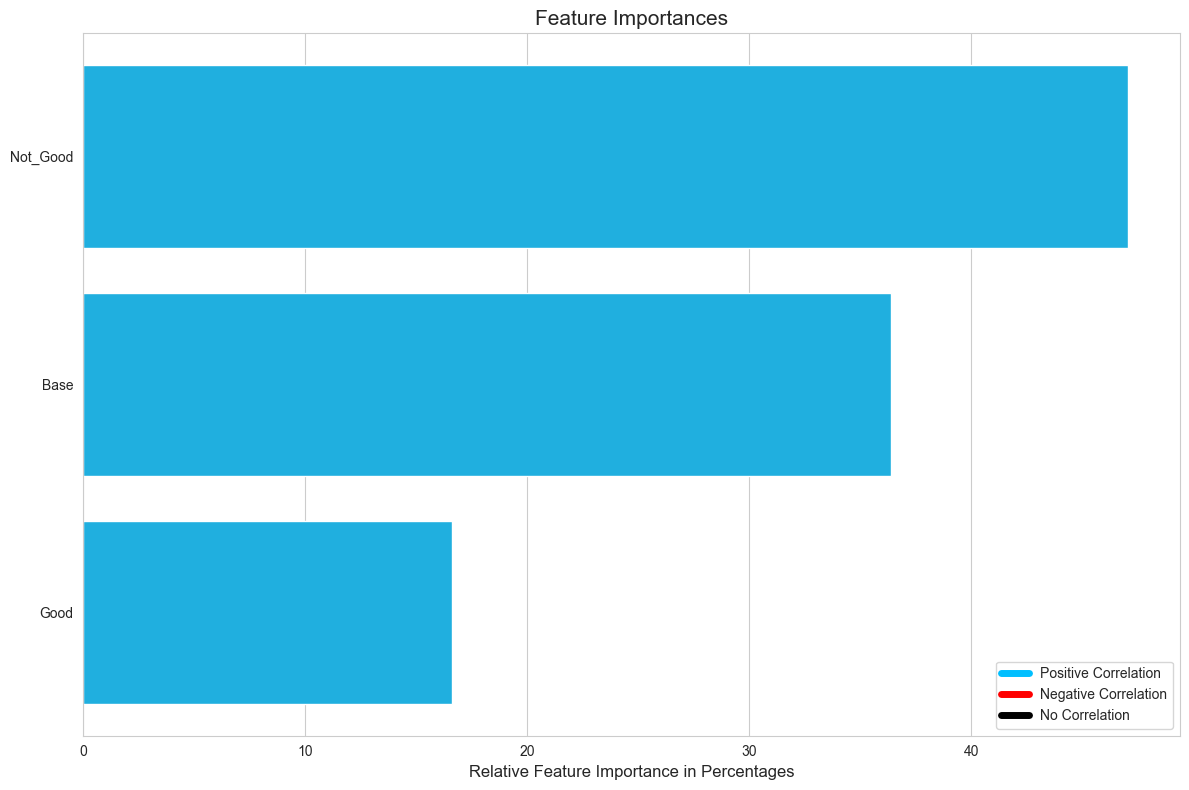

In [ ]:
pipeline_meta = Pipeline_Meta()
pipeline_meta.train(x_train=x_train_meta, y_train=y_train_meta, x_test = x_test_meta, y_test = y_test_meta)

In [ ]:
############ SAVE MODEL ############

model_path_meta = f'Models/meta_model_{version}.pkl'
with open(model_path_meta, 'wb') as out:
    pickle.dump(pipeline_meta.pipeline, out, pickle.HIGHEST_PROTOCOL)

In [ ]:
############ ADVANCED PIPELINE RESULTS ############

meta_test_proba_dict = pipeline_meta.apply(x_test_meta, y_test_meta)
meta_test_proba = meta_test_proba_dict["".join(key for key in meta_test_proba_dict if "Logistic Regression" in key)][0]
meta_test_proba = pd.DataFrame(meta_test_proba, index = y_test_meta.index)

2025-11-25 18:33:31,315 - qnbanalytics - INFO - Results of Logistic Regression
2025-11-25 18:33:31,316 - qnbanalytics - INFO - Train gini: 0.6089901965519309
2025-11-25 18:33:31,317 - qnbanalytics - INFO - CV gini: 0.6221983884492819
2025-11-25 18:33:31,318 - qnbanalytics - INFO - Valid gini: 0.5992995768276668
2025-11-25 18:33:31,318 - qnbanalytics - INFO - Test gini: 0.5992995768276668



In [ ]:
############ APPLY TO ALL DATA ############

all_x = pd.concat([x_train,x_test], axis = 0)
all_y = pd.concat([y_train,y_test], axis = 0)

# Get predictions and extract results (self-contained)
base_all_proba_dict = pipeline_base.apply(all_x, all_y)
lr_keys = [key for key in base_all_proba_dict.keys() if "Logistic Regression" in key]
if not lr_keys:
    raise KeyError(f"No 'Logistic Regression' key found. Available keys: {list(base_all_proba_dict.keys())}")
base_all_proba = base_all_proba_dict[lr_keys[0]][0]

not_good_all_proba_dict = pipeline_not_good.apply(all_x, all_y)
ng_keys = [key for key in not_good_all_proba_dict.keys() if f"{not_good_selected_model}" in key]
if not ng_keys:
    raise KeyError(f"No '{not_good_selected_model}' key found. Available keys: {list(not_good_all_proba_dict.keys())}")
not_good_all_proba = not_good_all_proba_dict[ng_keys[0]][0]

good_all_proba_dict = pipeline_good.apply(all_x, all_y)
g_keys = [key for key in good_all_proba_dict.keys() if f"{good_selected_model}" in key]
if not g_keys:
    raise KeyError(f"No '{good_selected_model}' key found. Available keys: {list(good_all_proba_dict.keys())}")
good_all_proba = good_all_proba_dict[g_keys[0]][0]

base_all_proba = pd.DataFrame(base_all_proba, index = all_y.index)
not_good_all_proba = pd.DataFrame(not_good_all_proba, index = all_y.index)
good_all_proba = pd.DataFrame(good_all_proba, index = all_y.index)

x_all_meta = pd.concat([base_all_proba,good_all_proba,not_good_all_proba], axis = 1)
x_all_meta.columns = ["Base","Good","Not_Good"]
y_all_meta = all_y

meta_all_proba_dict = pipeline_meta.apply(x_all_meta, y_all_meta)
lr_keys = [key for key in meta_all_proba_dict.keys() if "Logistic Regression" in key]
if not lr_keys:
    raise KeyError(f"No 'Logistic Regression' key found. Available keys: {list(meta_all_proba_dict.keys())}")
meta_all_proba = meta_all_proba_dict[lr_keys[0]][0]
meta_all_proba = pd.DataFrame(meta_all_proba, index = y_all_meta.index)




############ CALCULATE CREDIT SCORES ############

ref=200
odds_at_ref=100
points_to_double=20




default_rate = base_all_proba
default_rate = np.where(default_rate == 0, 0.00001, default_rate)

odds = (1/default_rate)-1

base_all_score = ((np.log(odds)-np.log(odds_at_ref))/np.log(2)) * (points_to_double) + ref
base_all_score = pd.DataFrame(base_all_score, index = all_y.index)




default_rate = meta_all_proba
default_rate = np.where(default_rate == 0, 0.00001, default_rate)

odds = (1/default_rate)-1

meta_all_score = ((np.log(odds)-np.log(odds_at_ref))/np.log(2)) * (points_to_double) + ref
meta_all_score = pd.DataFrame(meta_all_score, index = all_y.index)





all_scores = pd.concat([base_all_proba, base_all_score, meta_all_proba, meta_all_score, all_y], axis = 1)
all_scores.columns = ["BASIC_PROBA","BASIC_SCORE","BOOSTED_PROBA","BOOSTED_SCORE","TARGET"]
pd.DataFrame(all_scores).to_excel(f"Output/MAIN_SCORES_{version}.xlsx")


print("Runtime: %s" % (datetime.datetime.now()- start_time))